In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (891, 12)
Number of rows: 891
Number of columns: 12


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
summary_statistics = df.describe().T
summary_statistics

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [9]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()

print("Numeric columns:", numeric_columns)

Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


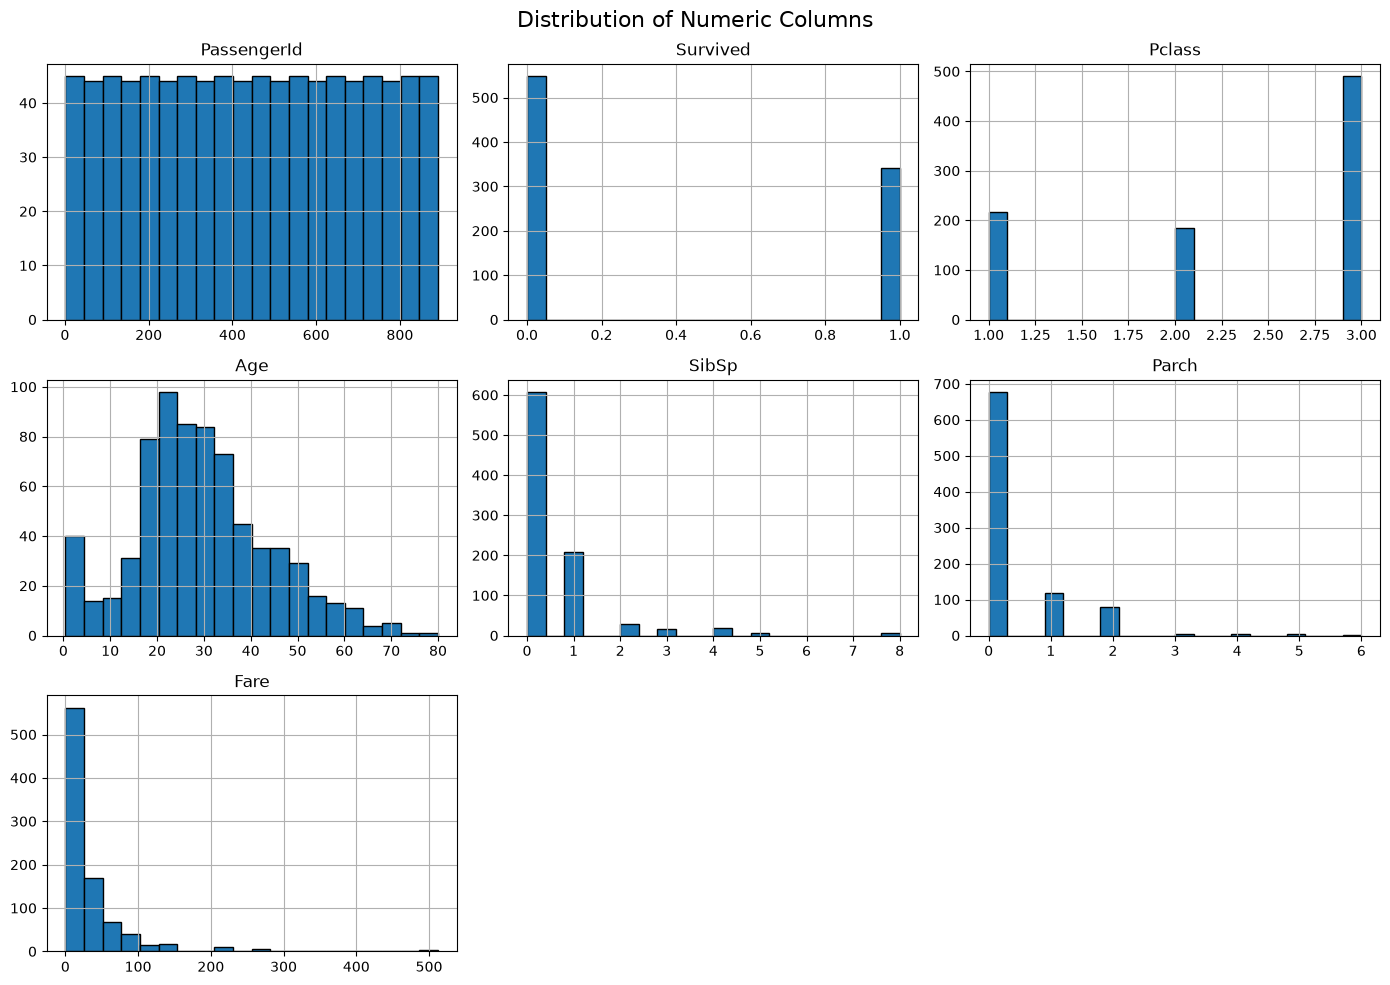

In [10]:
df[numeric_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Columns", fontsize=16)
plt.tight_layout()
plt.show()

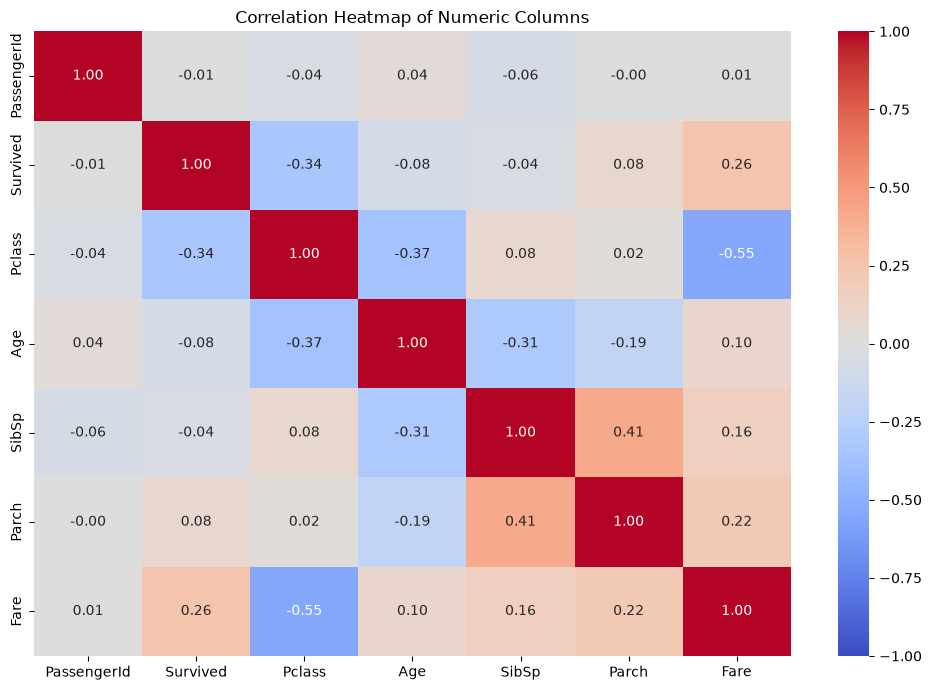

In [11]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Numeric Columns")
plt.tight_layout()
plt.show()

Overall survival rate: 38.38%


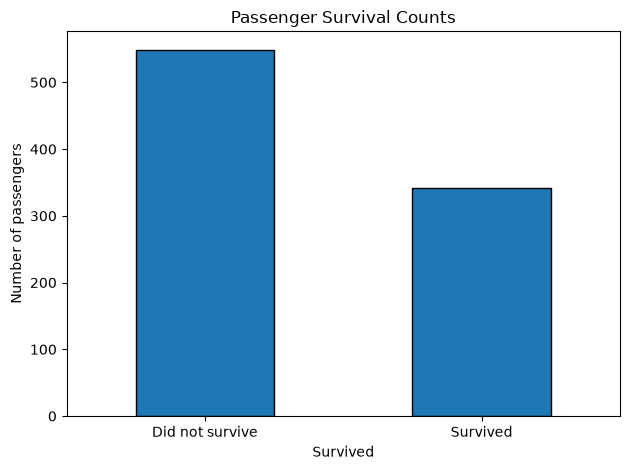

In [12]:
survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.2f}%")

survival_counts = df["Survived"].value_counts().sort_index()

survival_counts.plot(
    kind="bar",
    rot=0,
    edgecolor="black"
)

plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.ylabel("Number of passengers")
plt.title("Passenger Survival Counts")
plt.tight_layout()
plt.show()

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


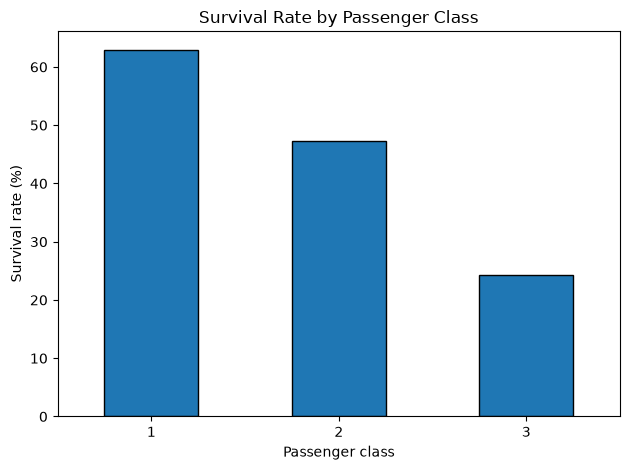

In [13]:
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
print(survival_by_class)

survival_by_class.plot(
    kind="bar",
    rot=0,
    edgecolor="black"
)

plt.xlabel("Passenger class")
plt.ylabel("Survival rate (%)")
plt.title("Survival Rate by Passenger Class")
plt.tight_layout()
plt.show()

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


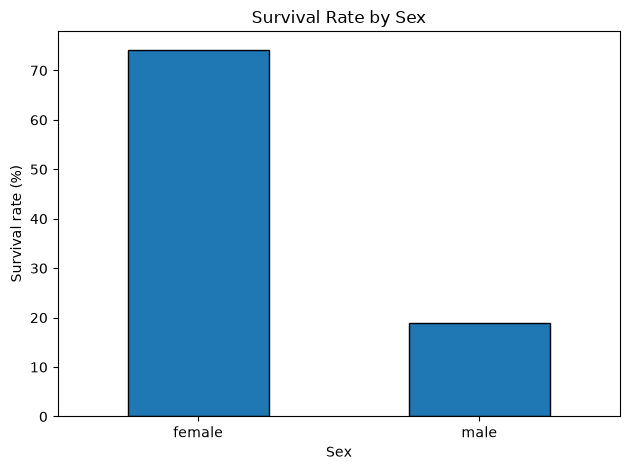

In [14]:
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
print(survival_by_sex)

survival_by_sex.plot(
    kind="bar",
    rot=0,
    edgecolor="black"
)

plt.ylabel("Survival rate (%)")
plt.title("Survival Rate by Sex")
plt.tight_layout()
plt.show()

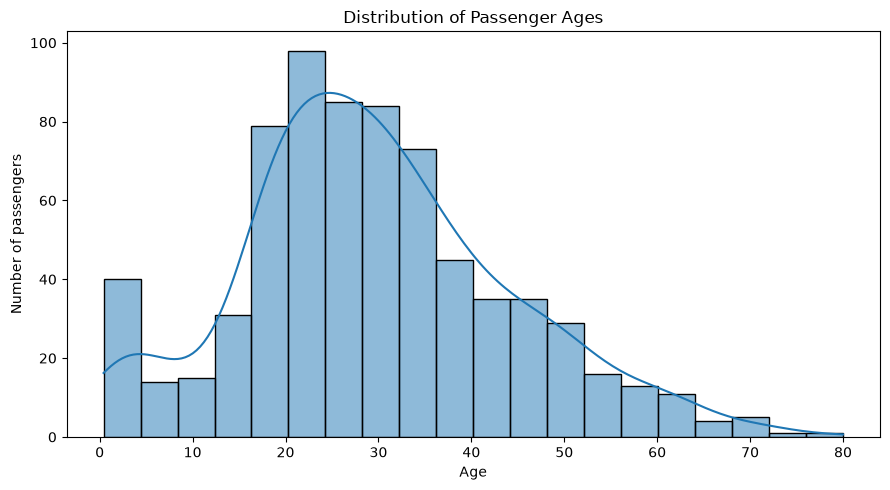

In [15]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.tight_layout()
plt.show()

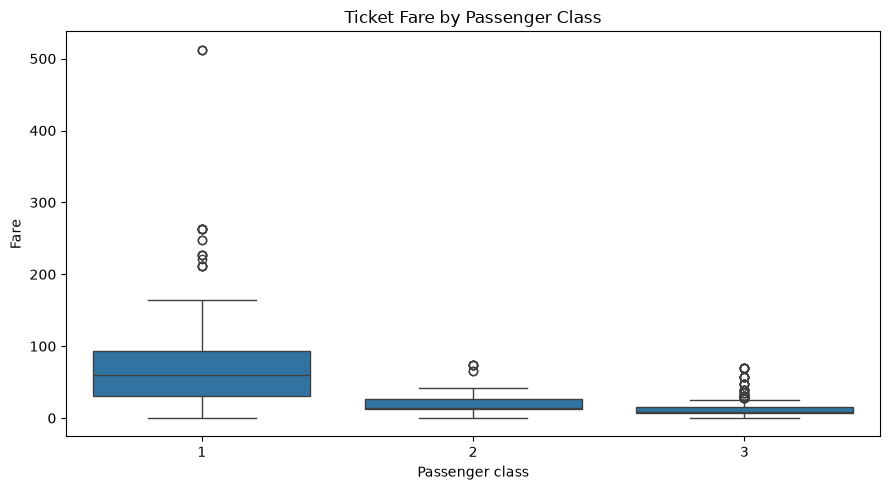

In [16]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Pclass", y="Fare")

plt.title("Ticket Fare by Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

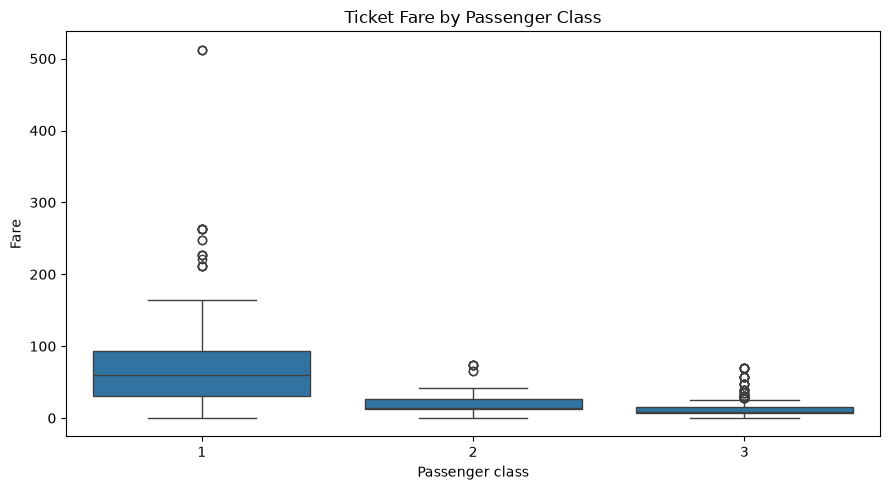

In [17]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Pclass", y="Fare")

plt.title("Ticket Fare by Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

In [18]:
print("EDA BUSINESS INSIGHTS")
print("-" * 40)

print(f"1. Overall survival rate: {df['Survived'].mean() * 100:.2f}%")

print(
    "2. Survival rate by passenger class:\n",
    (df.groupby("Pclass")["Survived"].mean() * 100).round(2)
)

print(
    "3. Survival rate by sex:\n",
    (df.groupby("Sex")["Survived"].mean() * 100).round(2)
)

print(
    "4. Median age:",
    round(df["Age"].median(), 2)
)

print(
    "5. Median fare by passenger class:\n",
    df.groupby("Pclass")["Fare"].median().round(2)
)

EDA BUSINESS INSIGHTS
----------------------------------------
1. Overall survival rate: 38.38%
2. Survival rate by passenger class:
 Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64
3. Survival rate by sex:
 Sex
female    74.20
male      18.89
Name: Survived, dtype: float64
4. Median age: 28.0
5. Median fare by passenger class:
 Pclass
1    60.29
2    14.25
3     8.05
Name: Fare, dtype: float64
